In [51]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
%pip install numpy
%pip install pandas
%pip install pytest
%pip install requests
%pip install ipywidgets
%pip install jupyter_ui_poll
%pip install python-dotenv

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrad

## config variables

In [53]:
from dotenv import load_dotenv
import os

load_dotenv()

email = os.getenv("MET_API_EMAIL")

location = input('Please provide a location: ')
if len(location) <= 0:
    raise ValueError('Invalid location name!')

## Http fundermentals

**Using urllib to get geocoding into**

In [54]:
import json
import urllib.parse
import urllib.request

base_url = "https://geocoding-api.open-meteo.com/v1/search"
time_out=10

try:
    params = {"name": location, "count": 1, "language": 'en', "format": 'json'}
    url = f"{base_url}?{urllib.parse.urlencode(params)}"
    with urllib.request.urlopen(url, timeout=time_out) as resp:
        results = json.load(resp).get("results", [])
        results[0]['latitude'], results[0]['longitude']

        print("Source: Open-Meteo Geocoding (geocoding-api.open-meteo.com/v1/search)\n" , f"Location:{location}\n", f"Latitude:{results[0]['latitude']}", f"Longitude:{results[0]['longitude']}")
except Exception as e:
    print(f"Error: {e}")   



Source: Open-Meteo Geocoding (geocoding-api.open-meteo.com/v1/search)
 Location:kampala
 Latitude:0.31628 Longitude:32.58219


**Using Requests to get geocoding info**

In [55]:
import json
import requests

base_url = "https://geocoding-api.open-meteo.com/v1/search"
time_out=10

try:
    params = {"name": location, "count": 1, "language": 'en', "format": 'json'}
    resp = requests.get(base_url, params=params, timeout=time_out)
    resp.raise_for_status()
    results = resp.json().get("results", [])
    results[0]['latitude'], results[0]['longitude']

    print("Source: Open-Meteo Geocoding (geocoding-api.open-meteo.com/v1/search)\n" , f"Location:{location}\n", f"Latitude:{results[0]['latitude']}", f"Longitude:{results[0]['longitude']}")
except Exception as e:
    print(f"Error: {e}")   

Source: Open-Meteo Geocoding (geocoding-api.open-meteo.com/v1/search)
 Location:kampala
 Latitude:0.31628 Longitude:32.58219


## Comparing urllib and requests

| | urllib | requests |
|---|---|---|
| How much code | More. I had to build the URL myself, open it, read the response and turn it into JSON. | Less. I pass the parameters in a dictionary and call `.json()` to get the data. |
| Handling errors | It raises different errors for different problems (`HTTPError` for a bad response, `URLError` for a network problem), so I have to catch each one. | `raise_for_status()` checks for a bad response, and `requests.RequestException` catches every kind of error in one go. |
| Sending headers | I have to create a `Request` object first to add headers. | I just pass `headers={...}` to `requests.get()`. |
| Encoding | I encode the URL with `urlencode` and decode the response myself. | It encodes the URL and decodes the response for me. |
| Installing | Nothing to install. It comes with Python. | I need to install it with `pip install requests`. |

urllib works without installing anything, but I had to write more code and handle more of the details myself. requests did the same job in fewer lines and was easier to read, so I would use it unless I couldn't install extra packages.

## Status code, the Content-Type header, and the response time 

In [56]:
import requests

base_url = "https://geocoding-api.open-meteo.com/v1/search"
time_out=10

try:
    params = {"name":location, "count": 1, "language": "en", "format": "json"}
    resp = requests.get(base_url, params=params, timeout=time_out)

    print("Status code:  ", resp.status_code)
    print("Content-Type: ", resp.headers["Content-Type"])
    print(f"Response time: {resp.elapsed.total_seconds() * 1000:.0f} ms")
except Exception as e:
    print(f"Error: {e}")   

Status code:   200
Content-Type:  application/json; charset=utf-8
Response time: 1003 ms


## Forecast retreival and display

In [57]:
from src.open_meteo import OpenMeteo
from IPython.display import display, Markdown

try:
    time_out =10
    n_days = 7
           
    wf =  OpenMeteo(email)          
    data = wf.geocode(location, time_out)
    if(data):
        fcst= wf.get_forecast(data['latitude'],data['longitude'], n_days, data['timezone'],time_out)
        if(fcst):
            display(Markdown(
                f"**Location:** {location}, **Country:** {data.get('country', '-')}, "
                f"**Time zone:** {fcst['timezone']}"
                ))
            display(wf.forecast_to_dataframe(fcst))
        
except Exception as e:
    print(f"Error: {e}")

**Location:** kampala, **Country:** Uganda, **Time zone:** Africa/Kampala

,Weather code,Weather,Max temperature (°C),Min temperature (°C),Precipitation (mm),Max wind speed (km/h)
Date,,,,,,
2026-10-07,95,Thunderstorm,28.0,18.6,14.7,13.2
2026-10-08,81,Moderate rain showers,27.0,18.0,5.7,10.0
2026-10-09,95,Thunderstorm,25.8,19.0,28.7,11.2
2026-10-10,81,Moderate rain showers,25.8,19.0,5.3,13.9
2026-10-11,95,Thunderstorm,24.8,18.2,21.9,12.2
2026-10-12,80,Slight rain showers,25.0,18.0,15.0,10.1
2026-10-13,80,Slight rain showers,25.6,18.4,6.5,15.7


## Report and summary

**Location:** kampala, **Country:** Uganda, **Time zone:** Africa/Kampala

**7-day forecast for kampala**
**From 07 Oct To 13 Oct 2026**

| Measure | Day | Value |
|---|---|---|
| Average daytime high | - | 26.0 °C |
| Average night-time low | - | 18.5 °C |
| Warmest day | Wed 07 Oct | 28.0 °C |
| Coldest day | Sun 11 Oct | 24.8 °C |
| Coolest night | Thu 08 Oct | 18.0 °C |
| Total rain | - | 97.8 mm |
| Rainy days (1 mm or more) | - | 7 of 7 |
| Wettest day | Fri 09 Oct | 28.7 mm |
| Driest day | Sat 10 Oct | 5.3 mm |
| Windiest day | Tue 13 Oct | 15.7 km/h |
| Most common conditions | - | Thunderstorm |

,Weather,Max temperature (°C),Min temperature (°C),Precipitation (mm),Max wind speed (km/h)
Date,,,,,
Wed 07 Oct,Thunderstorm,28.0,18.6,14.7,13.2
Thu 08 Oct,Moderate rain showers,27.0,18.0,5.7,10.0
Fri 09 Oct,Thunderstorm,25.8,19.0,28.7,11.2
Sat 10 Oct,Moderate rain showers,25.8,19.0,5.3,13.9
Sun 11 Oct,Thunderstorm,24.8,18.2,21.9,12.2
Mon 12 Oct,Slight rain showers,25.0,18.0,15.0,10.1
Tue 13 Oct,Slight rain showers,25.6,18.4,6.5,15.7


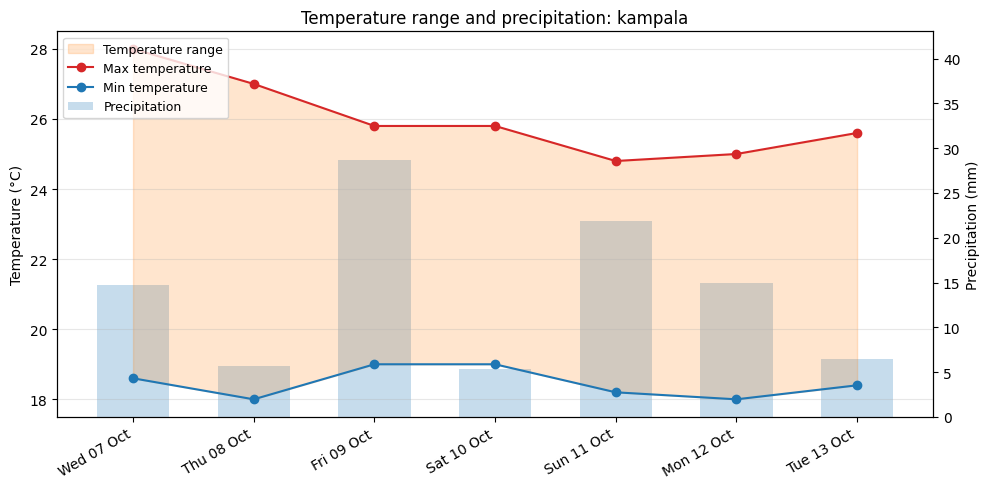

In [58]:
from src.weather_report import WeatherReport
from IPython.display import display, Markdown

try:
    if(fcst):
        dataframe =  wf.forecast_to_dataframe(fcst)
        display(Markdown( 
                    f"**Location:** {location}, **Country:** {data.get('country', '-')}, "
                    f"**Time zone:** {fcst['timezone']}"
                    ))
        report = WeatherReport(dataframe, location)
        report.show()
            
except Exception as e:
    print(f"Error: {e}")

## Robustness testing

In [59]:
import time
import requests
from unittest.mock import patch

from src.open_meteo import OpenMeteo

weather = OpenMeteo(email)

def run_case(title, func):
    """Run one test case and report the outcome instead of stopping the notebook."""
    print(f"=== {title} ===")
    start = time.perf_counter()
    try:
        result = func()
        print("Result:   no error (unexpected)", result)
    except Exception as e:
        print(f"Raised:   {type(e).__name__}")
        print(f"Message:  {e}")
        if e.__cause__ is not None:
            print(f"Cause:    {type(e.__cause__).__name__}")
    print(f"Time:     {time.perf_counter() - start:.2f} s\n")


# scenario 1. Invalid city
run_case("Invalid city",
         lambda: weather.geocode("Xyzzyqwertyville"))

# scenario 2. Invalid latitude
run_case("Invalid latitude (999)",
         lambda: weather.get_forecast(999, 32.58219))

#scenario 3. No network (simulated): every request raises ConnectionError.
#workflow: we alter run time request to fake connectivity issue
with patch("src.weather_forecast.requests.get", side_effect=requests.ConnectionError("Network is unreachable")) as fake_get, patch("src.weather_forecast.time.sleep") as fake_sleep:
    run_case("No network (simulated)", lambda: weather.get_forecast(0.31628, 32.58219))
    print(f"Attempts made:  {fake_get.call_count}")
    print(f"Backoff delays: {[c.args[0] for c in fake_sleep.call_args_list]} s\n")

#scenario 4. Tiny timeout: no real server can answer in 1 millisecond.
run_case("Tiny timeout (0.001 s)",
         lambda: weather.get_forecast(0.31628, 32.58219, time_out=0.001))

=== Invalid city ===
Raised:   ValueError
Message:  No results found for 'Xyzzyqwertyville'
Time:     0.94 s

=== Invalid latitude (999) ===
Raised:   HttpRequestException
Message:  Request Failed: Connection to https://api.open-meteo.com/v1/forecast failed after 1 attempt(s): HTTP 400 Bad Request
Cause:    HTTPError
Time:     0.92 s

=== No network (simulated) ===
Raised:   HttpRequestException
Message:  Request Failed: Connection to https://api.open-meteo.com/v1/forecast failed after 4 attempt(s): could not connect (Network is unreachable)
Cause:    ConnectionError
Time:     0.00 s

Attempts made:  4
Backoff delays: [1.0, 2.0, 4.0] s

=== Tiny timeout (0.001 s) ===
Raised:   HttpRequestException
Message:  Request Failed: Connection to https://api.open-meteo.com/v1/forecast failed after 4 attempt(s): timed out after 0.001 s
Cause:    ConnectTimeout
Time:     7.06 s



## Second source usage (Met Norway)

**Location:** kampala, **Country:** Uganda, **Time zone:** Africa/Kampala

**7-day forecast for kampala**
**From 07 Oct To 13 Oct 2026**

| Measure | Day | Value |
|---|---|---|
| Average daytime high | - | 24.4 °C |
| Average night-time low | - | 19.3 °C |
| Warmest day | Thu 08 Oct | 26.9 °C |
| Coldest day | Wed 07 Oct | 21.2 °C |
| Coolest night | Thu 08 Oct | 18.2 °C |
| Total rain | - | 110.6 mm |
| Rainy days (1 mm or more) | - | 6 of 7 |
| Wettest day | Mon 12 Oct | 32.9 mm |
| Driest day | Wed 07 Oct | 0.0 mm |
| Windiest day | Thu 08 Oct | 5.3 m/s |
| Most common conditions | - | Partly cloudy |

,Weather,Max temperature (°C),Min temperature (°C),Precipitation (mm),Max wind speed (m/s)
Date,,,,,
Wed 07 Oct,Clear sky,21.2,21.2,0.0,1.4
Thu 08 Oct,Partly cloudy,26.9,18.2,6.2,5.3
Fri 09 Oct,Partly cloudy,25.7,19.1,29.0,3.9
Sat 10 Oct,Partly cloudy,25.7,19.5,10.6,4.3
Sun 11 Oct,Heavy rain,23.6,19.4,24.1,3.3
Mon 12 Oct,Rain,22.4,19.2,32.9,1.5
Tue 13 Oct,Cloudy,25.6,18.4,7.8,3.8


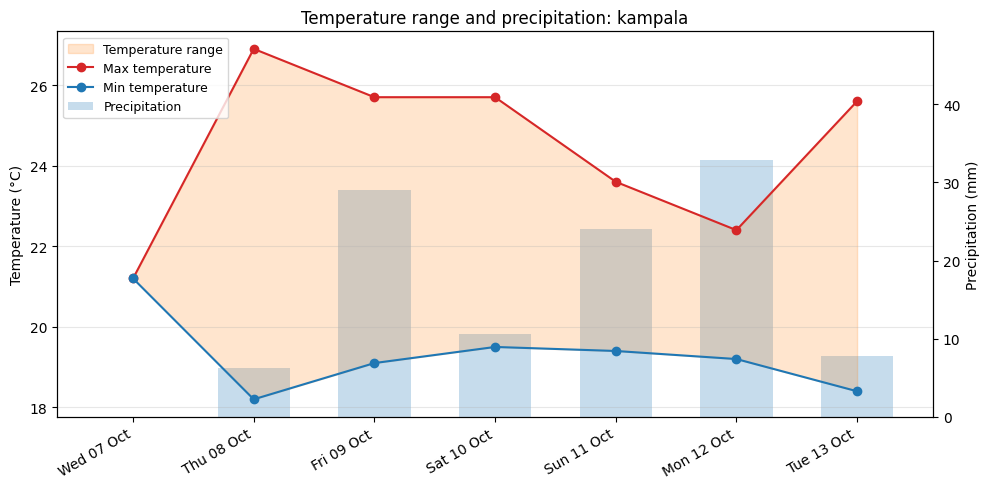

In [60]:
from src.met_norway import MetNorway
from src.weather_report import WeatherReport
from IPython.display import display, Markdown

try:
    time_out =10
    n_days = 7
    wf =   MetNorway(email)          
    if(data):
        fcst= wf.get_forecast(data['latitude'],data['longitude'], n_days, data['timezone'],time_out)
        if(fcst):
            dataframe =  wf.forecast_to_dataframe(fcst)
            display(Markdown( 
                    f"**Location:** {location}, **Country:** {data.get('country', '-')}, "
                    f"**Time zone:** {fcst['timezone']}"
                    ))
            report = WeatherReport(dataframe, location)
            report.show()
            
except Exception as e:
    print(f"Error: {e}")

## How the data flows

When you type a place name, the program goes through four steps to show you a forecast.

```
You type a place name, e.g. "kampala"
              │
              ▼
1. Find the place (Open-Meteo geocoding)
   If there are several matches, you pick one
              │
              ▼
   Latitude, longitude and time zone
              │
              ▼
2. Get the forecast from Open-Meteo or MET Norway
              │
              ▼
3. Turn the reply into a table (pandas DataFrame)
              │
              ▼
4. Show a summary, a forecast table and a chart
```

First, the program sends the place name to Open-Meteo's geocoding service. It sends back up to ten places with that name. Many names are shared by more than one town, so if there's more than one match, I list them and you choose the right one. The chosen place gives me its latitude, longitude and time zone.

Next, I ask a weather service for the forecast. I wrote one class for each service, `OpenMeteo` and `MetNorway`, and both follow the same pattern from a shared parent class called `WeatherForecast`. The parent class does the geocoding and sends all the web requests.

The two services reply in very different ways. Open-Meteo gives me one value per day, already in local time. MET Norway gives me the weather hour by hour in UTC, so I have to convert the times to local time and work out each day's highest and lowest temperature, total rain and strongest wind myself.

Both classes end up with the same kind of table, with the same column names. That means the last step, `WeatherReport`, works the same way whichever service I used.

## Licensing and usage terms

I used two weather services, and they have different rules.

### Open-Meteo

Open-Meteo is free and doesn't need a key, but only for non-commercial use. A school project like this is fine. An app with ads or paid subscriptions isn't, and would need a paid plan. The free version also has limits: under 10,000 requests a day, 5,000 an hour and 600 a minute. If an app misuses the service, Open-Meteo can block it.

The data is under a licence called CC BY 4.0. I'm allowed to use and change it, but I have to credit Open-Meteo, link to the licence and say if I changed anything. Open-Meteo asks for a "Weather data by Open-Meteo.com" link wherever the data appears. The place names come from GeoNames, which uses the same licence. Open-Meteo doesn't promise that the free service will always work or always be accurate.

### MET Norway

MET Norway is Norway's national weather service, and its data is free for anyone to use, including businesses, as long as MET Norway is credited. In return, it has strict technical rules:

- Every request has to say which app sent it and how to contact the developer.
- Coordinates can have at most four decimal places.
- Apps should save (cache) replies and not ask for the same data again too soon.
- An app can send at most 20 requests per second in total, unless MET Norway agrees to more.
- Apps that break the rules get slowed down or blocked.

MET Norway also doesn't promise the service will always be available.

### What this means for a real product

If I turned this into a paid app, I could keep using MET Norway for free, but I'd have to pay for Open-Meteo, including the geocoding, or switch to another place-search service. I'd need to show the right credit line on every screen with weather data. I'd also need my own server to save replies and pass requests along, so that thousands of users aren't all calling the weather services directly.

Right now my notebook names the data source in its printed output, but the report doesn't include the credit links yet. I'd add them before sharing it.

## Reliability issues and how my code handles them

### When the network fails

Every request has a time limit, so the program can't hang forever waiting for a reply. If the connection fails, the request times out, or the server has an error of its own (a 5xx code), the program waits and tries again, up to three more times. Each wait is twice as long as the one before: 1 second, then 2, then 4. Problems like these are often temporary, and waiting gives the server a chance to recover. If all four attempts fail, the program raises my own error, `HttpRequestException`, with a message saying what went wrong.

If the server says the request itself is wrong (a 4xx code), for example because the latitude is 999, the program gives up straight away. Sending the same bad request again would just fail again.

### Testing with broken inputs

I tested four broken cases: a city that doesn't exist, an impossible latitude, no internet connection and a tiny time limit. To fake "no internet", I swapped the real request function for a fake one that always fails. These tests found two bugs in my code. The first made the program crash with a confusing error when every attempt failed. The second made timeouts show up as connection failures, because my error checks were in the wrong order. After fixing both, each case gives its own clear message.

### My own mistakes

At one point I had the geocoding and forecast web addresses swapped, so the place name went to the wrong service and the reply couldn't be read. Another time I called a method on the class itself instead of on an object, which shifted all the arguments by one. In the future I'd print the web address and the reply before reading it, which would have shown me both problems quickly.

### MET Norway's extra rules

MET Norway refuses requests that don't say who sent them, and coordinates with more than four decimals. My geocoding results had five, so I round them before sending. MET Norway also gives two rain amounts at each point in time, one for the next hour and one for the next six hours, and they overlap. If I added them all up, I'd count some rain twice, so my code only uses one amount for each stretch of time.

### Missing or unclear data

If a place isn't found, the program says so clearly instead of crashing. If a name matches several places, it asks you to choose. If a place has no region or country listed, it shows a dash, and unknown weather types show as "Unknown".

### Still to do

The program doesn't yet handle "too many requests" errors (code 429), doesn't save replies to reuse later, and doesn't check MET Norway's warning for old versions of the service. A real app would need all three.

## Privacy

Every time someone checks the weather, the program tells another company about a place they care about. The place name always goes to Open-Meteo. The coordinates then go to Open-Meteo or MET Norway, so with MET Norway, two different organisations see the search.

Each request also shares the user's IP address, which shows roughly where they are. One search doesn't say much, but many searches from the same address could show where someone lives, works or is planning to travel. If an app sent the phone's exact GPS position, it could point to one building. My program sends the centre of a town instead, which is much less exact.

Both services say what they do with this information. Open-Meteo says it may keep IP addresses to keep its servers running and stop misuse, doesn't share its logs, and deletes them after 90 days. MET Norway says it keeps users' IP addresses and coordinates in its logs, stored in its own data centre in Norway. MET Norway itself suggests sending requests through your own server, so it never sees users' IP addresses. In both cases I'm trusting their word, and their policies could change.

There's also my own privacy. MET Norway needs contact details with every request, so my email address goes out with each one. It's also visible in my public GitHub project. For a real product, I'd use a project email instead of my personal one.

Laws such as the EU's GDPR and Uganda's Data Protection and Privacy Act, 2019 treat location as personal data. So a real app should tell users where their searches go and collect only what it needs. A few simple steps would help:

- Round the coordinates to two decimal places. That's about 1 km, which is close enough for a forecast but doesn't give away an exact address.
- Send all requests through the app's own server, so the weather services never see users' IP addresses.
- Save forecasts for popular places, so fewer searches leave the app.
- Don't keep logs of what places users search for, or delete them quickly.

None of these changes the forecast the user sees, but they protect where users are.